<a href="https://colab.research.google.com/github/leesihwan21/AI_26/blob/main/07_03_%EC%9D%B8%EA%B3%B5%EC%8B%A0%EA%B2%BD%EB%A7%9D%EA%B8%B0%ED%83%80%EB%8F%84%EA%B5%AC(%EB%93%9C%EB%A1%AD%EC%95%84%EC%9B%83%2C%EC%BD%9C%EB%B0%B1%2C%EC%A1%B0%EA%B8%B0%EC%A2%85%EB%A3%8C).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 금 -> 시험.(위주로 공부), 막대 차트에 있는 것들 스케일조정 해야함. 시험문제

# 인공신경망을 구성하는 절차
# 1. 더미데이터 준비
# 2. 훈련용, 검증용, 테스트용으로 나눔
# 3. 심층을 만듬(dense)
# 4. model에 적용 (Sequential, 순차적)
# 5. 컴파일 진행(최적화기법을 적용 : adam)
# 6. fit(훈련)
# 7. evaluate(검증)
# 8. predict(예측)

In [2]:
# 손실곡선 : fit() 메서드로 모델을 훈련하는 동안 훈련과정이
# 상세하게 출력되어 확인 할 수 있다. (에포크 횟수, 손실, 정확도)
# 아래쪽에  이 출력 메시지가 나옴
# 코렙 노트북에 코드셀은 print() 명령어를 사용하지 않아도 마지막 라인에 실행결과를 자동으로 출력

# 다시말해 fit() 메서드는 History라는 클래스 객체를 반환 함 (훈련과정의 지표, 손실, 정확도 등 내장)
# 이 값을 잘 활용하면 그래프를 그릴 수 있다.

In [3]:
import tensorflow as tf

tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

from tensorflow import keras
from sklearn.model_selection import train_test_split

(train_input, train_target), (test_input, test_target) =\
     keras.datasets.fashion_mnist.load_data()
# 엔터효과 제거용 \ -> 한줄로 긴 문장을 자름.

train_scaled = train_input / 255.0

train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [4]:
print("훈련데이터 :")
print(train_scaled.shape, train_target.shape)
print("테스트데이터 :")
print(test_input.shape, test_target.shape)
print("검증데이터 :")
print(val_scaled.shape, val_target.shape)

훈련데이터 :
(48000, 28, 28) (48000,)
테스트데이터 :
(10000, 28, 28) (10000,)
검증데이터 :
(12000, 28, 28) (12000,)


In [5]:
# 모델을 만드는 함수를 정의함 (하나의 매개변수를 받아 리턴) .model_fn(dense추가하면 생성)
def model_fn(a_layer=None):
  # model_fn : 함수를 정의함.
  # a_layer 라는 매개변수를 받는데, 기본값을 None 으로 설정. 즉, 인자 없이 호출하면 층을 추가하지 않고 기본 모델만 만듬.
    model = keras.Sequential()
    # 케라스의 순차 모델객체를 생성함.
    # 특징 : 층을 차례차례 쌓아서 만드는 가장 직관적인 모델 형태.
    model.add(keras.layers.Flatten(input_shape=(28, 28)))   # 반복적으로 사용되는 입력 층
    # 2차원 데이터를 1차원 으로 쫙 펼쳐주는 입력층을 추가함.
    # 특징 : 28 x 28 크기의 이미지 데이터를 784(28 x 28) 개의 1차원 배열로 바꿔줌.
    # 신경망의 첫 번째 층에서 주로 사용됨.
    model.add(keras.layers.Dense(100, activation='relu'))   # 반복적으로 사용되는 2진분류 층
    # 100개의 뉴런을 가진 밀집층(은닉층)을 추가하고 , 활성화 함수(relu) 를 사용함
    # 이미지의 특징을 학습하는 주된 층. relu는 학습을 빠르고 안정적으로 도와줌.

    # model_fn() 함수에 (a_layer 매개변수로) 케라스 층을 추가하면 은닉층 뒤에 하나의 층을 추가함.
    if a_layer:
        model.add(a_layer)                                  # 매개값으로 넘어오는 추가되는 층
        # 만약 함수를 호출 할때 a_layer 자리에 무언가를 전달했다면, 그 층을 모델에 추가함.
        # 이 함수를 호 출할 때마다 모델 구조를 유연하게 바꿀 수 있게 해주는 아주 핵심적 코드.
    model.add(keras.layers.Dense(10, activation='softmax')) # 반복적으로 사용되는 다중분류 층
    # 10개의 뉴런을 가진 출력층을 추가하고, 활성화 함수로 softmax를 사용함
    # 특징 : 패션 MINIST 는 10개의 클래스 (옷종류)를 분류하므로 뉴런이 10개이다. softmax는 각 클래스일 확률을 출력해줌.
    return model

In [6]:
model = model_fn()    # 위에서 만든 메서드 호출해서 모델이란 변수에 담음.
#       model_fn(매개값이 없으면 그냥 생성, 매개값이 있으면 모델 추가용)
model.summary()       # 모델의 요약정보를 봄.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])
#                   categorical -> 다중분류,                     정확도

In [8]:
# history = fit() 메서드 결과를 -> history 변수에 담아 봄
history = model.fit(train_scaled, train_target, epochs=5, verbose=1) # 28초 정도 걸림
#                                                         훈련과정 출력을 조절함. verbose
#                     verbose=0 이면 훈련과정을 나타내지 않음
#                     verbose=1 이면 기본값, 에포크마다 진행 막대와 함께 손실등의 지표가 출력
#                     verbose=2 이면 진행 막대 빼고 출력.

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7620 - loss: 0.6785
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8521 - loss: 0.4056
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8686 - loss: 0.3600
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8788 - loss: 0.3362
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8849 - loss: 0.3192


In [9]:
print(history)    # 위에 .fit() 한 결과를 History 클래스라는 객체가 가지고 있는데 이것을 history 변수에 넣음.

In [10]:
print(history.history.keys())
# 훈련 측정 값이 담겨 있는 history 딕셔너리가 존재함.
# 정확도 accuracy. 손실 loss 값이 있다.

# 정확도는 compile() 메서드의 metrics 매개변수에 accuracy 를 추가했기 때문에
# history 속성에 포함되어 있음.

dict_keys(['accuracy', 'loss'])


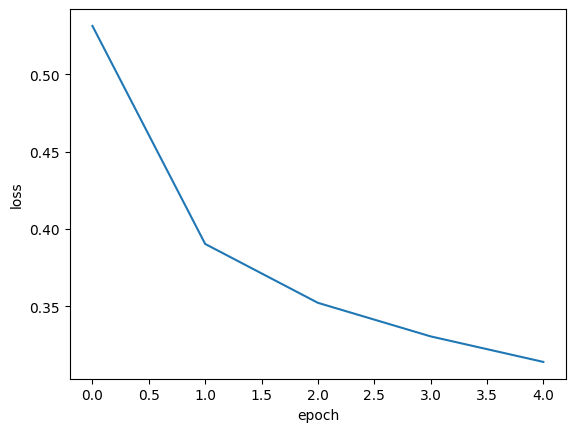

In [12]:
import matplotlib.pyplot as plt

# history 속성에 포함된 손실과 정확도는 에포크마다 계산한 값이
# 순서대로 나열된 단순한 리스트로 맷플롯립으로 쉽게 그래프 처리가 가능하다.
plt.plot(history.history['loss'])
plt.xlabel('epoch')
# 파이썬 인덱스는 0부터 시작함. 왜? 리스트 배열이기때문에 1차원.
# 5개의 에포크가 0~4까지 x축에 포함.
plt.ylabel('loss')    # 손실 값
plt.show()

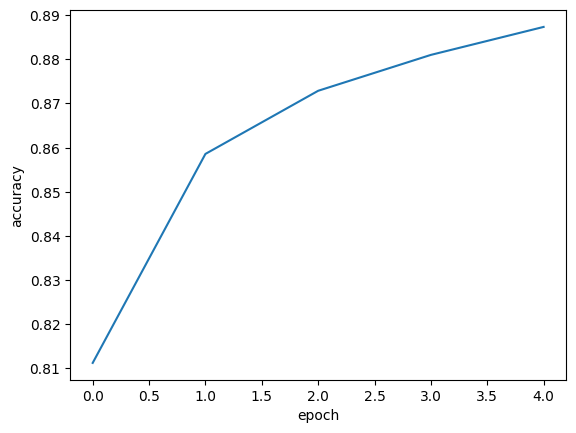

In [13]:
# 이번에는 정확도를 출력
plt.plot(history.history['accuracy'])
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

# 결과분석 : 에포크마다 손실이 감소하고 정확도가 향상됨. 위 사진과 비교

In [14]:
# 이번에는 에포크 횟수를 20번으로 늘려서 보자.

model = model_fn()    # 위에서 만든 메서드로 모델 생성(3개층 : 입력층, 은닉층, 출력층)
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(train_scaled, train_target, epochs=20, verbose=1) # 약 1분정도걸림. verbose 기본값 1로 설정 진행막대 보기위해서 설정.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7639 - loss: 0.6860
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8497 - loss: 0.4148
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8668 - loss: 0.3680
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8765 - loss: 0.3408
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8848 - loss: 0.3195
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8912 - loss: 0.3052
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8958 - loss: 0.2926
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8999 - loss: 0.2836
Epoch 9/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9039 - loss: 0.2760
Epoch 10/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9074 - loss: 0.2676
Epoch 11/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9094 - loss: 0.2600
Epoch 12/20
1500/1500 ━━━━━━━━

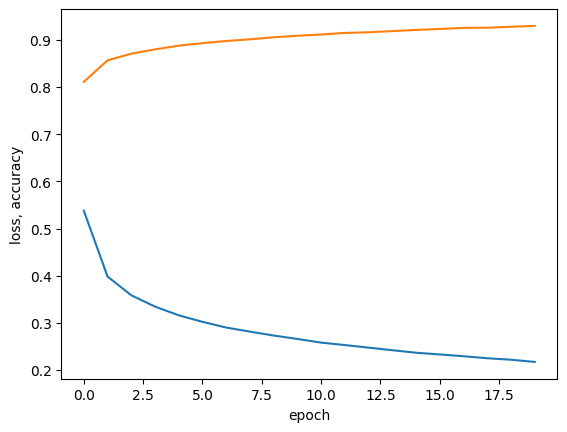

In [15]:
plt.plot(history.history['loss'])  #손실율
plt.plot(history.history['accuracy'])
plt.xlabel('epoch')
plt.ylabel('loss, accuracy')
plt.show()

In [16]:
# 검증 손실 validate_date=(val_scaled,val_target)
# 예전에 확률적 경사 하강법을 사용 했을 때, 과대적합/과소적합 에포크 사이에 상관관계 부분이 있다.
# 인공 신경망은 모두 일종의 경사 하강법을 사용하기 때문에 동일한 개념이 여기에도 적용된다.

# 에포크에 따른 과대적합, 과소적합을 파악하려면 훈련 세트 점수와 검증 세트에 대한 점수도 필요함.
# 그래서 위에 처럼 훈련세트에 손실과 정확도만 그리면 파악이 어렵다.
# 검증 손실을 이용해 과대/과소 적합을 응용하겠다.
# keypoint https://wikidocs.net/236194
# 손실을 사용하는 것과 정확도를 사용하는 것의 차이는???????????????????????????????????????????
# 인공 신경망 모델이 최적화하는 대상은 정확도가 아니라 손실 함수임
# 손실 감소에 비례하여 정확도가 높아지지 않는 경우는 있는데
# 모델이 잘 훈련 되었는지 판단하려면 정확도 보다는 손실 함수의 값을 확인하는 것이 더 좋은 방법이다.

In [18]:
model = model_fn()
model.summary()
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(train_scaled, train_target, epochs=20, verbose=1,
                    validation_data=(val_scaled, val_target))
#                   검증손실을 구하기위한 매개값 추가 됨 3분걸림

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7637 - loss: 0.6723 - val_accuracy: 0.8473 - val_loss: 0.4305
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8518 - loss: 0.4061 - val_accuracy: 0.8569 - val_loss: 0.3989
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8691 - loss: 0.3596 - val_accuracy: 0.8613 - val_loss: 0.3856
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8801 - loss: 0.3348 - val_accuracy: 0.8627 - val_loss: 0.3884
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8861 - loss: 0.3174 - val_accuracy: 0.8674 - val_loss: 0.3788
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8916 - loss: 0.3045 - val_accuracy: 0.8651 - val_loss: 0.3914
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8985 - loss: 0.2929 - val_accuracy: 0.8648 - val_loss: 0.4089
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9017 - loss: 0.2839 - 

In [19]:
print(history.history.keys())
# 정확도 accuracy, 손실 loss 값이 있다.
# 추가로 검증세트 정확도 val_accuracy, 검증세트 손실 val_loss 가 나옴.

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


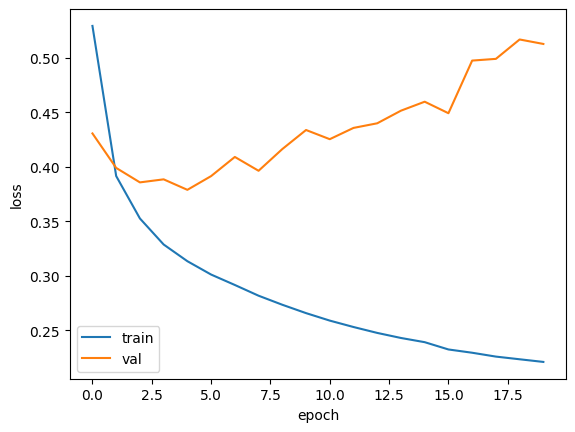

In [21]:
# 과대/과소 적합 문제를 조사하기 위해서 훈련손실, 검증 손실을 한 그래프에 그려서 비교해보자.
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train','val'])
plt.show()
# 결과 분석 : 초기에 검증 손실이 감소하다가 다섯 번째 에포크 만에 다시 상승함.
# 훈련 손실은 꾸준하게 감소하기 때문에 과대 적합 모델이 만들어 짐
# 검증 손실이 상승하는 시점을 가능한 늦추면 세트에 대한 손실이 줄어들고
# 검증 세트에 대한 정확도가 증가할 것 같다.

# 과대 적합을 막기 위한 방법으로는 예전에 사용했던 규제방식대신에(릿지, 라쏘)
# 신경망에 특화된 규제방법(드롭아웃) 을 나중에 해보자.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


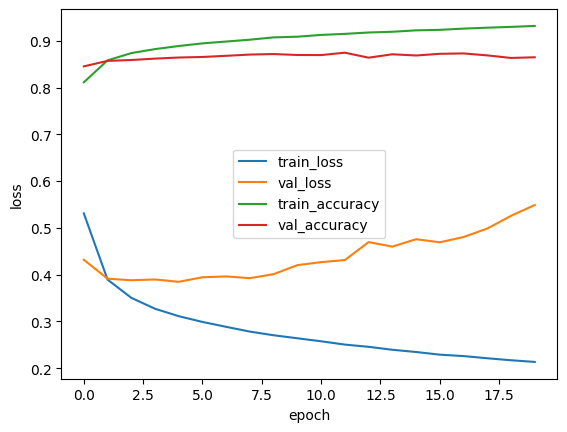

In [24]:
# 지금은 옵티마이져(최적화) 하이퍼 파라미터를 자동 조절해서 과대 적합을 완화시켜본다.
# RMSprop 옵티마이져는 많은 문제에서 잘 ~ 동작합니다. -> 다른 방법으로는 Adagrad, Adam 등이 있죠.
model = model_fn()
model.compile(optimizer='RMSprop', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(train_scaled, train_target, epochs=20, verbose=0,
                    validation_data=(val_scaled, val_target))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train_loss', 'val_loss', 'train_accuracy', 'val_accuracy'])
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


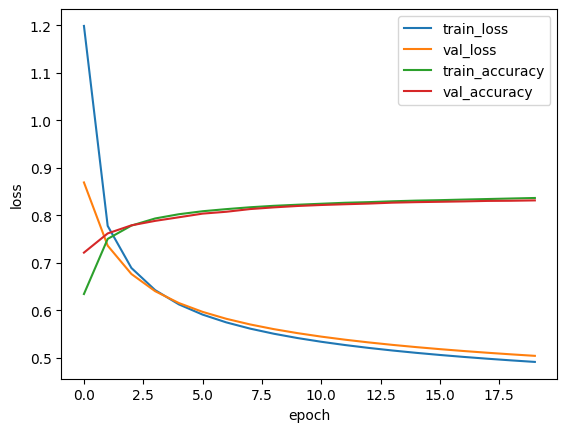

In [25]:
model = model_fn()
adagrad = keras.optimizers.Adagrad()     # Adagrad 기법으로 최적화 후 차트로 확인하자.
model.compile(optimizer=adagrad, loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_scaled, train_target, epochs=20, verbose=0,
                    validation_data=(val_scaled, val_target))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train_loss', 'val_loss', 'train_accuracy', 'val_accuracy'])
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


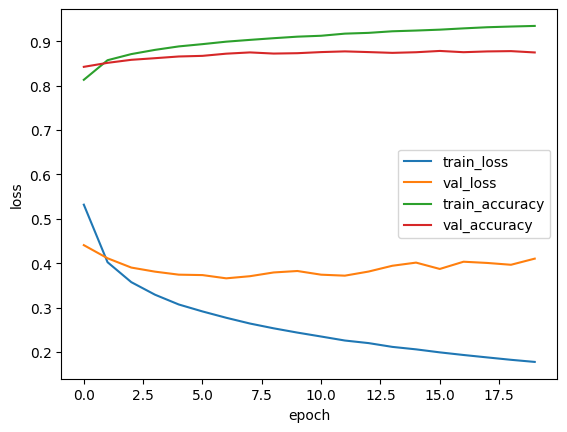

In [26]:
model = model_fn()

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_scaled, train_target, epochs=20, verbose=0,
                    validation_data=(val_scaled, val_target)) # 2분 28초 정도 걸림

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train_loss', 'val_loss', 'train_accuracy','val_accuracy'])
plt.show()
# 3가지의 최적화 기법을 사용해보니 adam이 안정적으로 보인다.
# 대신에, 과대적합을 막기 위한 기법이 필요해 보인다.

In [27]:
# 이제, 위 사진을 드롭아웃(Dropout)을 시켜보겠다.
# 드롭아웃 (Dropout)은 딥러닝의 기초가 되는 제프리 힌턴이 소개 하였다.
# 훈련과정에서 층에 있는 일부 뉴런을 랜덤하게 꺼서 (뉴런 출력을 0으로 만듬) 과대 적합을 만듬.

# 어떤 샘플을 처리할 때 은닉층의 두 번째 뉴런이 드롭아웃되어 h2 출력이 없음
# 다른 샘플을 처리할 때 은닉층의 첫 번재 뉴런이 드롭아웃되어 h1 출력이 없음
# 뉴런은 랜덤하게 드롭아웃 되고 얼마나 많은 뉴런을 드롭할지 우리가 하이퍼 파라미터에 정할 것임

# 드롭아웃이 왜 과대 적합을 막을 수 있을지 생각해보면 이전 층의 일부 뉴런이 랜덤하게 꺼지면 OFF
# 특정 뉴런에 과대하게 의존하는 것을 줄일 수 있고 모든 입력에 대해서 주의를 기울여야 함.
# 일부 뉴런의 출력이 없을 수 있다는 것을 감안하면 이 신경망은 더 안정적인 예측을 만들 수 있는 곳.

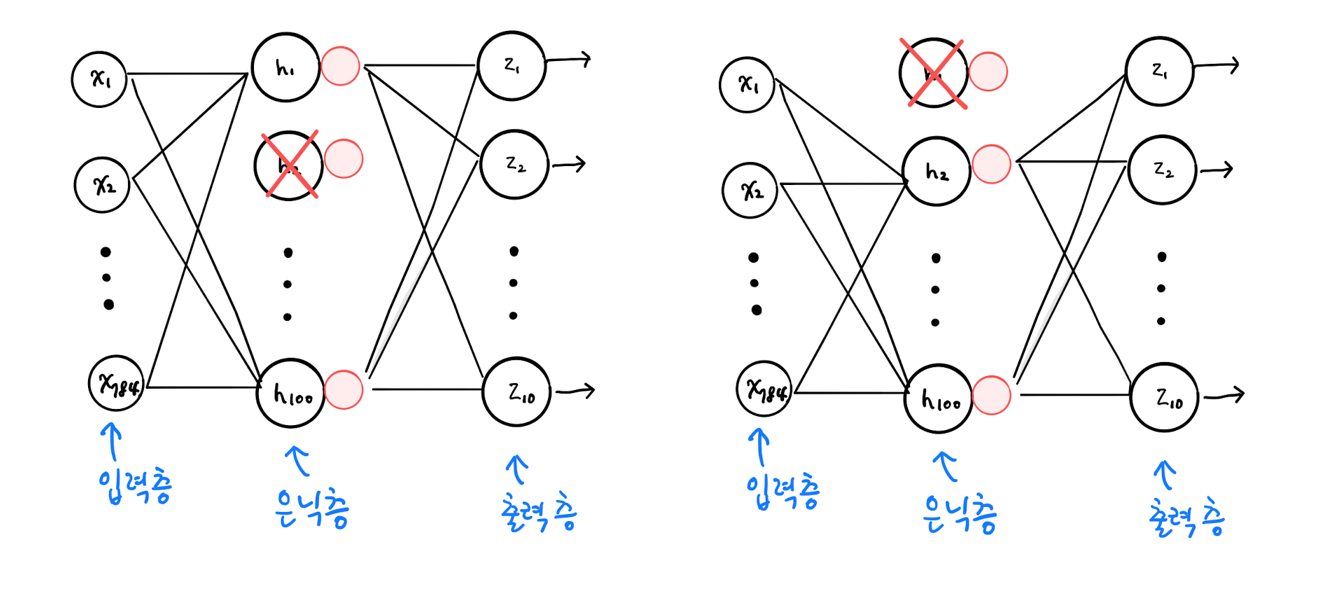

In [28]:
# 또 다른 분석
# 앞의 드롭아웃이 적용된 2개의 신경망 그림을 보면
# 드롭아웃을 적용해 훈련하는 것은 마치 2개의 신경망을 트리의앙상블하는 것처럼 상상하게 됨
# 앙상블 : 다 좋은 예측을 만들기 위해서 여러 개의 모델을 훈련하는 머신러닝 알고리즘
#     과대 적합을 막아주는 좋은 기법

# 케라스에서 드롭아웃을 keras.layers.Dropout 로 제공함.
# 어떤 층의 뒤에 드롭아웃을 두어 이 층의 출력을 랜덤하게 0으로 만듬
# 드롭아웃이 층처럼 사용되지만 훈련되는 파라미터는 없음

# model_fn() 함수에 드롭 아웃 객체를 전달하여 층을 추가함.
model = model_fn(keras.layers.Dropout(0.3))    # 30% 정도 드롭 아웃

model.summary()  # 요약 확인
# 은닉층 뒤에 추가된 드롭아웃 층(3번째 값) 은 훈련되는 모델 파라미터가 없음.
# 입력과 출력의 크기가 같음
# 일부 뉴런의 출력을 0으로 만들지만 전체 출력 배열의 크기를 바꾸지 않음

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_9 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

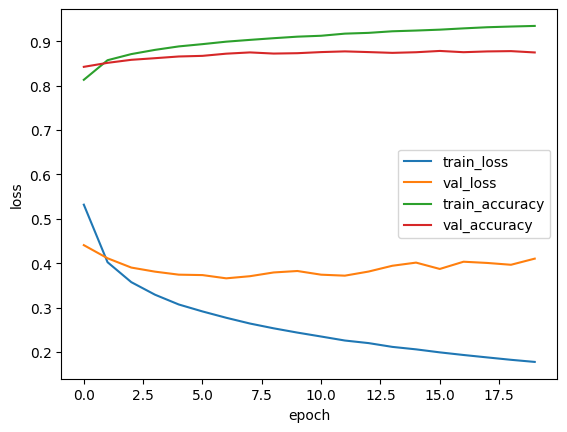

In [29]:
# 주의사항 : 훈련이 끝난 뒤 평가나 예측을 수행할 때는 반드시 드롭아웃을 적용하지 않는다.
# 훈련된 모든 뉴런을 사용해야 올바른 예측이 수행됨
# 텐서플로와 케라스는 모델을 평가와 예측에 사용할 때 자동으로 드롭아웃을 적용하지 않음

# 훈련 손실과 검증 손실의 그래프를 그려보자.
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

histroy = model.fit(train_scaled, train_target, epochs=20, verbose=0,
                    validation_data=(val_scaled, val_target))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train_loss','val_loss','train_accuracy','val_accuracy'])
plt.show()
# 과대 적합이 확실히 줄어 들 10번째 에포크가 검증 손실의 감소가 멈추지만 크게 상승하지 않음
# 20번의 에포크를 실행해서 결국 과대 적합이 되었음 -> 10번만 해볼까? (조기종료해서 해보자.)

In [30]:
# 차후에 재활용하기 위해서 모델 저장과 복원도 해본다.
model = model_fn(keras.layers.Dropout(0.3))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_scaled, train_target, epochs=10, verbose=0,
                    validation_data=(val_scaled, val_target))

model.save('model-whole-ep10.keras')  # 모델 저장

# 케라스 모델은 훈련된 모델의 파라미터를 저장하는 save_weights() 메서드가 있다.
# 텐서플로의 체크포인트 포멧으로 저장하지만 https://www.tensorflow.org/guide/checkpoint?hl=ko
# .h5일 경우 HDF5 포멧으로 저장함 https://geunuk.tistory.com/466

model.save_weights('model-ep10.weights.h5')   # HDF5 형식으로도 저장됨 (폴더에서 확인)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [31]:
# model.save("model.keras") : 모델 전체를 저장(자동차 설계도 + 엔진 + 연료 상태 모두 저장)
# 저장되는 것 : 모델 구조 (Layer 구조) / 학습된 가중치 / 옵티마이져 상태 / 컴파일 정보 (loss, metrics 등)
# 즉 완전히 동일한 모델을 바로 복원 가능
# model = load_model("model.keras") : 모델 불러오기
# 코드 없이도 바로 복원 가능 -> 배포 / 추론용으로 많이 사용

# model.save_weights("model.weights.h5") : 가중치만 저장(엔진만 저장)
# 저장되는 것 : 학습된 weights
# 저장되지 않는것 : 모델 구조 / optimizer 상태 / compile 정보
# model = create_model()   # 동일한 구조 다시 생성
# model.load_weights("model_weights.h5")
# 모델 구조 코드를 다시 만들어야 함 -> 실험 중간 체크포인트로 많이 사용

# 오해금지! -> 더미데이터는 저장하지 않는다.
# 모델이 데이터 대신 기억하는 것은 패턴(가중치) 입니다.
# 훈련 데이터 (길이, 높이, 두께) → 생선 무게
# 훈련 후 모델이 저장하는 것 -> weight1 = 0.23 / weight2 = 1.52 / bias = -0.77
# 데이터 → 학습 → 가중치

In [32]:
# model.keras (케라스모델 구조 : with zipfile.ZipFile("model.keras", 'r') as z:
#                                print(z.namelist()) )
#                                ['config.json', 'metadata.json', 'model.weights.h5']
#  ├ config.json
#  ├ metadata.json
#  └ model.weights.h5

# config.json (모델 구조)
# {
#  "class_name": "Sequential",
#  "config": {
#    "layers": [
#      {
#        "class_name": "Dense",
#        "config": {
#          "units": 64,
#          "activation": "relu"
#        }
#      }
#    ]
#  }
# }


# model.weights.h5 (가중치)
# dense/kernel:0
# dense/bias:0
# dense_1/kernel:0
# dense_1/bias:0
# -> 실제 값 : 가중치만 저장(엔진만 저장)
#  0.2312
# -0.7811
#  0.5321

# metadata.json
# {
#  "keras_version": "3.0",
#  "backend": "tensorflow"
# }

In [33]:
# 이제는 저장한 모델을 불러와 테스트를 진행 해보자.
!ls -al model*

-rw-r--r-- 1 root root 976600 Mar  5 03:28 model-ep10.weights.h5
-rw-r--r-- 1 root root 979412 Mar  5 03:28 model-whole-ep10.keras


In [34]:
# 실험1
# 훈련하지 않은 새로운 모델을 만들고 model-ep10.weights.h5 파일에서
# 훈련된 모델 파라미터를 읽어서 사용

# model_fn() 위와 동일한 모델
model = model_fn(keras.layers.Dropout(0.3)) # 훈련하지 않은 새로운 모델

model.load_weights('model-ep10.weights.h5')   # 이전에 저장했던 모델 파라미터를 로딩
# 이 때 사용하는 메서드는 save_weight() 와 쌍을 이루는 load_weight() 메서드 임
# 주의사항 : load_weights() 메서드를 사용하려면 save_weight() 메서드로 저장했던 모델과
# 정확히 같은 구조를 가져야함.

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_11 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
# 모델의 검증 정확도를 확인 해보자.
import numpy as np

# predict() 메서드는 사이킷 런과 다른 샘플마다 10개의 클래스에 대한 확률을 반환 (다중분류)

# 패션 MNIST 데이터셋에서 덜어낸 검증 세트의 샘플수는 12,000개이기 때문에
# predict()메서드는 (12000, 10)크기의 배열을 반환
# 10개의 확률 중 가장 큰 값의 인덱스를 골라(.argmax) 타킷 레이블과 비교하여 정확도를 계산해보자
val_labels = np.argmax(model.predict(val_scaled), axis=-1)

# axis=-1 배열의 마지막 차원을 따라 최대값을 고름
# 검증세트는 2차원 배열이기 때문에 마지막 차원은 1이 됨
# 예를 들어 아래 그림처럼 5x3배열에 axis=1로 한값과 axis=0으로 한 값의 인덱스를 반환함

# argmax()로 고른 인덱스(val_labels)와 타킷(val_target)을 비교하여 같으면 1이되고 다르면 0이됨
# 이를 평균으로 출력해 봄(정확도)
print(np.mean(val_labels == val_target)) # 87.96% 평균

# axis=1 이면 열을 따라 각 행의 최대값의 인덱스를 선택하고
# axis=0 이면 행을 따라 각 열의 최대값의 인덱스를 선택함.
# 그 다음 라인은 argmax()로 고른 인덱스(val_labels)와 타킷(val_target)을 비교
#   -> 두 배열에서 각 위치의 값이 같이면 1, 다르면 0 (평균하면 정확도가 됨)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
0.877


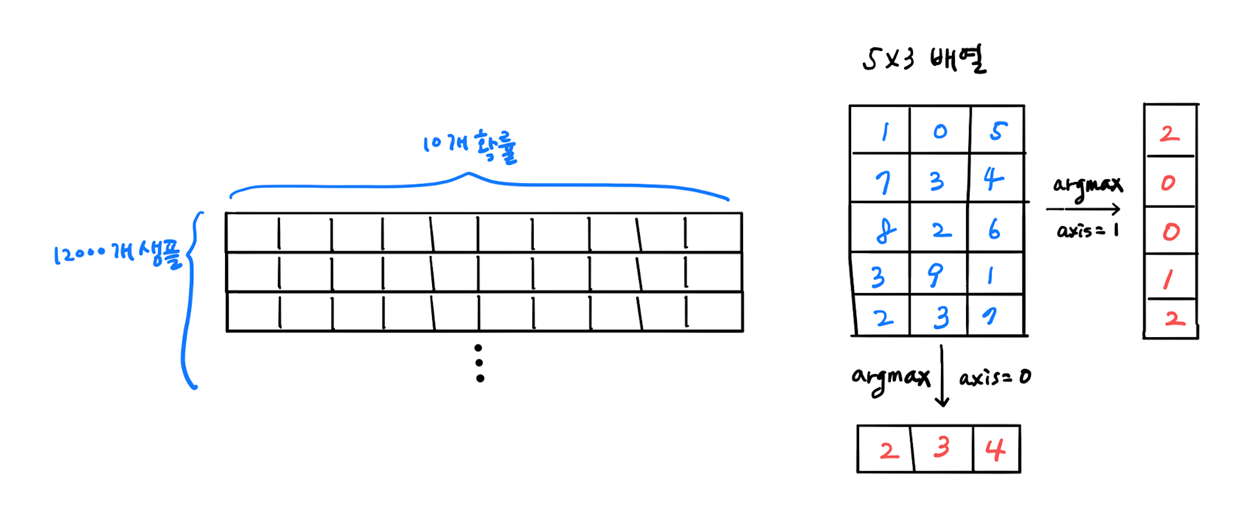

In [39]:
# 모델 전체를 파일에서 읽은 다음 검증 세트의 정확도를 출력 해봄.
model = keras.models.load_model('model-whole-ep10.keras')  # load_model() 저장된 케라스 파일 읽기

model.evaluate(val_scaled, val_target)  # 같은 모델을 불러 들였기 때문에 위와 정확도가 같음

# 현 상태 분석 : 20번의 에포크 동안 훈련해서 검증 점수가 상승하는 지점을 확인
# 모델을 과대적합 되지 않은 에포크만큼 다시 훈련함
# 모델을 두 번씩 훈련하지 않고 한 번에 끝내는 방법을 연구 해보자. -> 케라스 콜백

# https://ltlkodae.tistory.com/13 케라스 모델을 저장하는 방법 2가지 분석

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8810 - loss: 0.3350


[0.3384065330028534, 0.8769999742507935]

In [40]:
# 실험2
# 아예 파일로 새로운 모델을 만들고 바로 사용해 보자.
# 추가적으로 콜백이라는 것을 활용 해보자.
# 콜백 : 훈련과정 중간에 어떤 작업을 수행할 수 있게 하는 객체, 케라스, 콜백 패키지에 있다.
# fit() 메서드의 callback 매개변수에 리스트로 전달하여 사용
# 지금 우리가 사용할 콜백은 ModelCheckpoint 콜백으로 에포크마다 모델을 저장함.
# save_best_only=True 매개변수를 지정하여 가장 낮은 검증 점수를 만드는 모델을 저장할 수 있다.

model = model_fn(keras.layers.Dropout(0.3))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

checkpoint_cb = keras.callbacks.ModelCheckpoint('best-model.keras',
                                                save_best_only=True)

model.fit(train_scaled, train_target, epochs=20, verbose=1,
          validation_data=(val_scaled, val_target),
          callbacks=[checkpoint_cb])
# 모델 훈련 후 best-model.keras에 최상의 검증 점수를 낸 모델이 저장됨.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7306 - loss: 0.7712 - val_accuracy: 0.8453 - val_loss: 0.4242
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8374 - loss: 0.4548 - val_accuracy: 0.8577 - val_loss: 0.3833
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8518 - loss: 0.4145 - val_accuracy: 0.8689 - val_loss: 0.3652
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8596 - loss: 0.3871 - val_accuracy: 0.8680 - val_loss: 0.3558
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8656 - loss: 0.3708 - val_accuracy: 0.8747 - val_loss: 0.3417
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8688 - loss: 0.3562 - val_accuracy: 0.8751 - val_loss: 0.3346
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8715 - loss: 0.3478 - val_accuracy: 0.8775 - val_loss: 0.3331
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8761 - loss: 0.3381 -

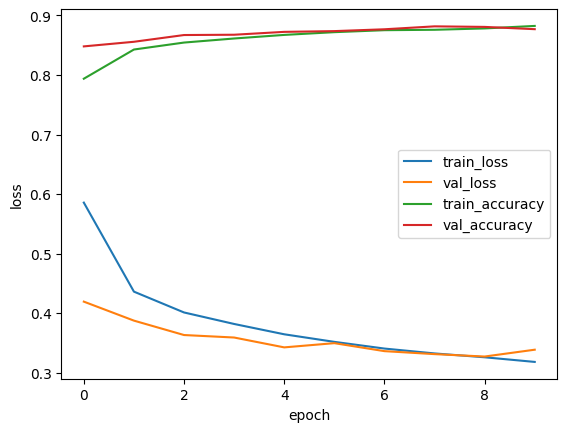

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8883 - loss: 0.3260


[0.33143556118011475, 0.8871666789054871]

In [41]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train_loss','val_loss','train_accuracy','val_accuracy'])
plt.show()
model.evaluate(val_scaled, val_target)    # 검증세트의 성능 확인 (33.10%, 87.99%) 에포크 9번
# 결론 20번을 다 돌리고 가장 좋은 점수가 나온 9번째 에포크를 저장함.

In [42]:
# keras.callbacks.ModelCheckpoint 콜백이 가장 낮은 점수의 모델을 자동으로 저장해 주었다.
# 여전히 20번의 에포크 동안 훈련을 함.
# 사실 검증 점수가 상승하기 시작하면 그 이후에는 과대 적합이
# 더 커지기 때문에 훈련을 계속할 필요가 없음
# 이 때 훈련을 종료하면 자원과 시간을 아낄 수 있음 -> 조기종료(early stopping)

# 조기 종료는 딥러닝 분야에 많이 사용하는 기법
# 에포크의 횟수를 제한하는 역할이지만 모델이 과대적합 되는 것을 막아주기도 함 -> 규제방법중에 하나.

In [43]:
# 케라스에는 조기종료를 위한 EarlyStopping 콜백을 제공함.
# 이 콜백의 patience 매개변수는 검증 점수가 향상되지 않더라도 "허용할" 에포크 횟수로 지정함.
# patience=2 -> 2번 연속 검증 점수가 향상되지 않으면 훈련을 중지함. (patience:인내심)
# restore_best_weights=True -> 가장 낮은 점수 손실을 낸 모델 파라미터로 돌림

model = model_fn(keras.layers.Dropout(0.3))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

checkpoint_cb = keras.callbacks.ModelCheckpoint('best-model.keras',
                                                save_best_only=True)
# 가장 낮은 검증 손실의 모델을 파일에 저장하고 검증 손실이 다시 상승할 때 훈련을 중지할 수 있음
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2,
                                                  restore_best_weights=True) # 얼리 종료. 얼리

# 훈련을 중지하고 현재 모델의 파라미터를 최상의 파라미터로 되돌림.
history = model.fit(train_scaled, train_target, epochs=20, verbose=1,
                    validation_data=(val_scaled, val_target),
                    callbacks=[checkpoint_cb, early_stopping_cb])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7266 - loss: 0.7919 - val_accuracy: 0.8414 - val_loss: 0.4355
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8372 - loss: 0.4564 - val_accuracy: 0.8520 - val_loss: 0.4022
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8496 - loss: 0.4185 - val_accuracy: 0.8648 - val_loss: 0.3676
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8554 - loss: 0.3942 - val_accuracy: 0.8684 - val_loss: 0.3628
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8642 - loss: 0.3715 - val_accuracy: 0.8702 - val_loss: 0.3529
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8678 - loss: 0.3628 - val_accuracy: 0.8737 - val_loss: 0.3456
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8721 - loss: 0.3496 - val_accuracy: 0.8721 - val_loss: 0.3487
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8783 - loss: 0.3376 

In [44]:
print(early_stopping_cb.stopped_epoch)    # 조기종료 시점 에포크

12


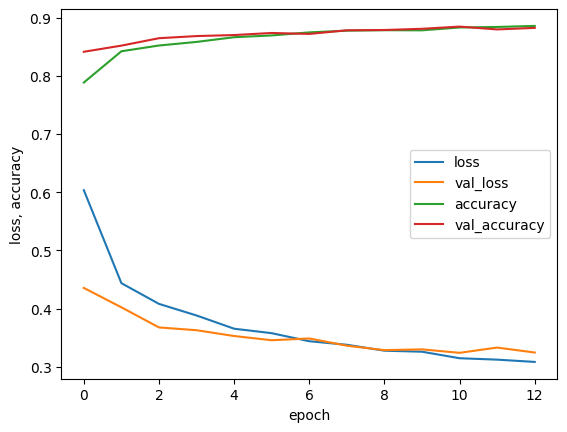

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8864 - loss: 0.3235


[0.32399022579193115, 0.8846666812896729]

In [46]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('loss, accuracy')
plt.legend(['loss', 'val_loss','accuracy', 'val_accuracy'])
plt.show()
model.evaluate(val_scaled, val_target)   # 검증세트의 성능 확인 (32.49%, 88.09%) 에포크 10번
# 컴퓨터의 자원과 시간을 아끼고 콜백과 함께 사용하면 최상의 모델을 자동으로 저쟁해 준다는 것을 명심.